In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
df = pd.read_csv('train.csv', index_col = 'PassengerId')
#load train data for analysis and deal index is PassengerId

### looking for head and tail data

In [3]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.info()
#info about number of samples and data types

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [6]:
df.describe()
#basic statistics about numeric data

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


По описанию стат.характеристик числовых данных, можно заметить пропуски в колонке возраста, а так же узнать информацию о среднем значении представленных признаков. Но подробнее каждый признак будет рассмотрен ниже.

In [7]:
df.shape
# У нас 891 строка(пассажира) и 11 признаков, изначально их было 12, но признак PassengerId я сделал новыми индексами

(891, 11)

### Проверка на пропуски в данных


In [8]:
df.isnull().sum().sort_values(ascending=False)

Cabin       687
Age         177
Embarked      2
Name          0
Pclass        0
Survived      0
Sex           0
Parch         0
SibSp         0
Fare          0
Ticket        0
dtype: int64

Из анализа пропусков данных, пропуски есть в признаках Cabin - номера кают где распологался пассажир, Age - возраст пассажиров, Embarked - порт отправления.

В дальнейшем мы будем решать, что делать с данными пропусками, но скорее всего номера кают исключу из-за слишком большого числа пропусков и невозможности чем-то заменить. А возраст и порт отправления надо будет проверить подробнее.

In [9]:
alive = df['Survived'].value_counts()[1]
died = len(df) - alive
print(f"alive = {alive}, died = {died}")

alive = 342, died = 549


Рассчитали количество выживших и умерших пассажиров

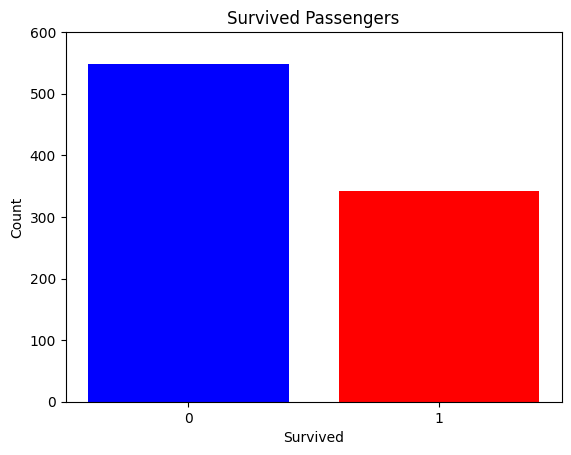

<Figure size 800x600 with 0 Axes>

In [10]:
labels = ['0', '1']
values = [died, alive]
colors = ['blue', 'red']

bars = plt.bar(labels, values, color=colors)

plt.xlabel('Survived')
plt.ylabel('Count')
plt.yticks(np.arange(0, 700, 100))
plt.title("Survived Passengers")

plt.figure(figsize= (8, 6))
plt.show()

<Axes: >

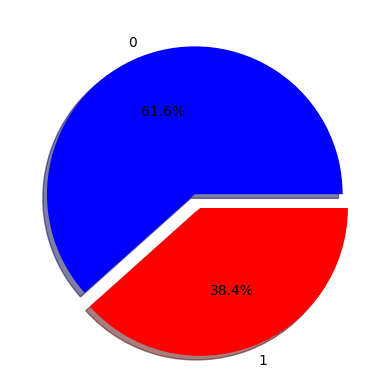

In [11]:
colors = ['blue', 'red']
df['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%', colors=colors, shadow=True)

Порядка 62% погибло, и 38% выжило

У нас есть несколько фич, которые надо будет перекодировать, чтобы использовать в анализе:
1) Категориальные фичи, в данном датасете это Пол(Sex) и порт отправления(Embarked)
2) Ранговые(порядковые) фичи это в нашем датасете - Pclass, класс которым путешествовал пассажир
3) Непрерывные фичи - это возраст Age



In [12]:
df.groupby(['Sex','Survived'])['Survived'].count()


Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

Узнали количество выжившыхи и погибших сгруппировав по полу
-------------------
Как можно заметить, мужчин погибло сильно больше чем женщин, при это количество выживших женщин от их общего числа достаточно велико. Можно предположить, что женщин спасали в первую очередь, поэтому такая не сбалансированность.

Text(0.5, 1.0, 'Survived: Dead vs Alive')

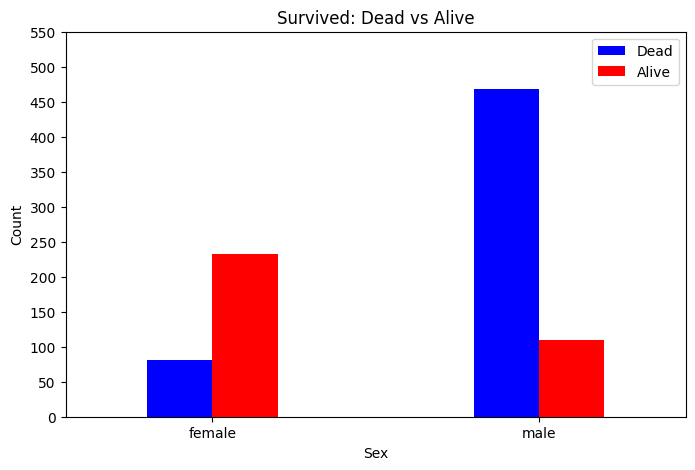

In [13]:
df_sex_count = (df.groupby(['Sex','Survived'])['Survived'].size().unstack(fill_value=0))

colors = ['blue', 'red']
df_sex_count.plot.bar(
    color=colors,
    width=0.4,
    figsize=(8, 5)
)

plt.xlabel('Sex')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.yticks(np.arange(0, 600, 50))
plt.legend(['Dead', 'Alive'])
plt.title('Survived: Dead vs Alive')


Построили график показывающий наглядо разницу в выживших и погибшим сгруппированным по полу.

Женщин выжило большинство, среди мужчин разительно меньше.

In [14]:
df[['Sex', 'Survived']].groupby(['Sex']).count()

,Survived
Sex,
female,314
male,577


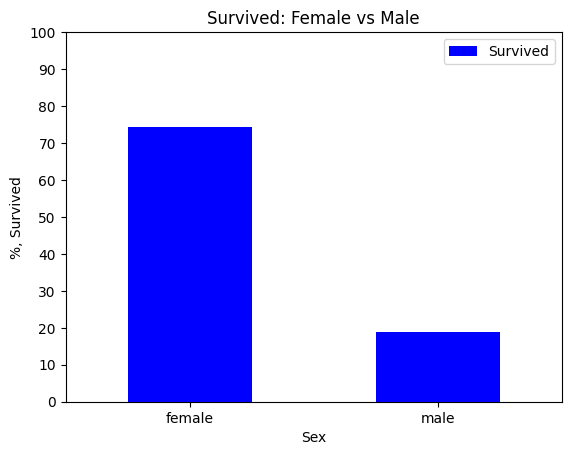

<Figure size 1000x600 with 0 Axes>

In [15]:
df_sex = pd.DataFrame(df[['Sex', 'Survived']].groupby(['Sex']).mean() * 100)

colors = ['blue']
labels = ['female', 'male']
df_sex.plot.bar(
    color=colors,
    label=labels
)

plt.xlabel('Sex')
plt.xticks(rotation=0)
plt.ylabel('%, Survived')
plt.yticks(np.arange(0, 110, 10))
plt.title('Survived: Female vs Male')
plt.figure(figsize=(10, 6))
plt.show()


По исследованию фичи Пола(Sex) можно сделать вывод, о том, что фича очень важная, так как мужчин выживает почти в два раза меньше чем женщин, и среди самих женщин выживаемость около 75 процентов, а среди мужчин около 18-20 процентов. То есть, при предсказании, скорее всего, пол будет сильно влиять, так как женщин выжило больше.

In [16]:
df[["Pclass", "Survived"]].groupby(['Pclass']).count()
#Общее количество людей отнесенных к соот-ему классу


,Survived
Pclass,
1,216
2,184
3,491


In [17]:
df[["Pclass", "Survived"]].groupby(['Pclass']).mean()
#Процент выживших пассажиров из 1, 2, и 3 классов

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [18]:
df[["Pclass", "Survived"]].groupby(['Pclass']).sum()
#Сколько выжило пассажиров относящихся к соот-му классу

,Survived
Pclass,
1,136
2,87
3,119


Уже на основании данных вычислений можно сделать предположение, что класс которым ехал пассажир влияет на выживаемость, так как среди первого класса выживаемость достигла 63%, во втором классе 47%
и в третьем классе 24%. 

Скорее всего класс будет влиять на предсказание о выживаемости

Text(0.5, 1.0, 'Number of Passengers By Class')

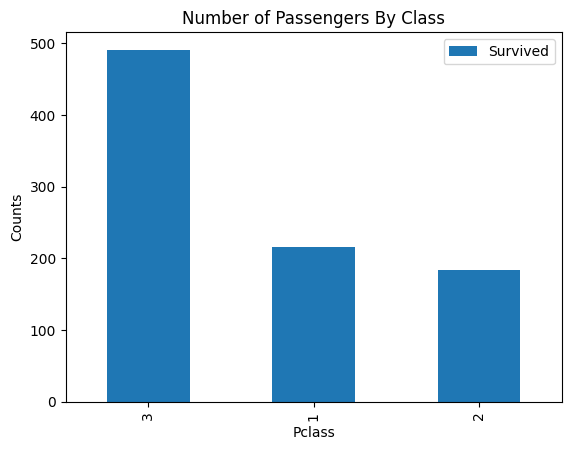

In [19]:
df_class_pnumber = pd.DataFrame(
    df[["Pclass", "Survived"]]
    .groupby(['Pclass'])
    .count()
    .sort_values(by='Survived', ascending=False)
)


bars = df_class_pnumber.plot.bar()
plt.ylabel('Counts')
plt.title('Number of Passengers By Class')

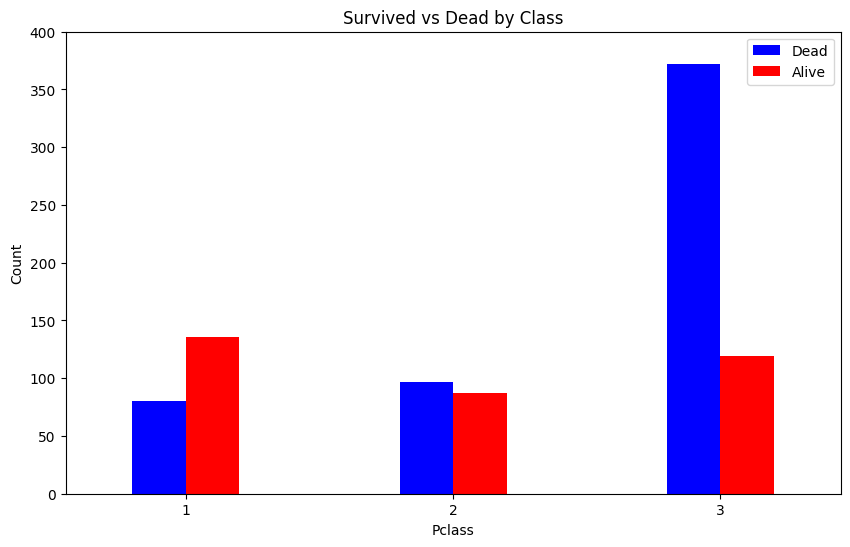

In [20]:
df_class_surv = pd.DataFrame(
    df[["Pclass", "Survived"]]
    .groupby(['Pclass', 'Survived'])
    .size()
    .unstack()
)

colors = ['blue', 'red']

df_class_surv.plot.bar(
    color=colors,
    width=0.4,
    figsize=(10,6)
)

plt.xlabel('Pclass')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 450, 50))
plt.legend(['Dead', 'Alive'])
plt.title('Survived vs Dead by Class')
plt.show()

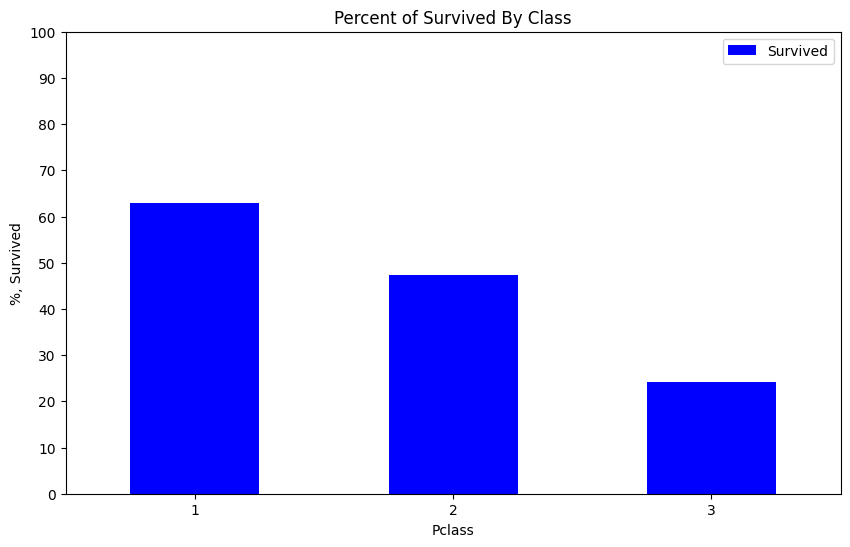

In [21]:
percent_alive_per_class = df[["Pclass", "Survived"]].groupby(['Pclass']).mean() * 100

colors = ['blue']
percent_alive_per_class.plot.bar(
    color=colors,
    figsize=(10, 6)
)

plt.xlabel('Pclass')
plt.ylabel('%, Survived')
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 110, 10))
plt.title("Percent of Survived By Class")
plt.show()

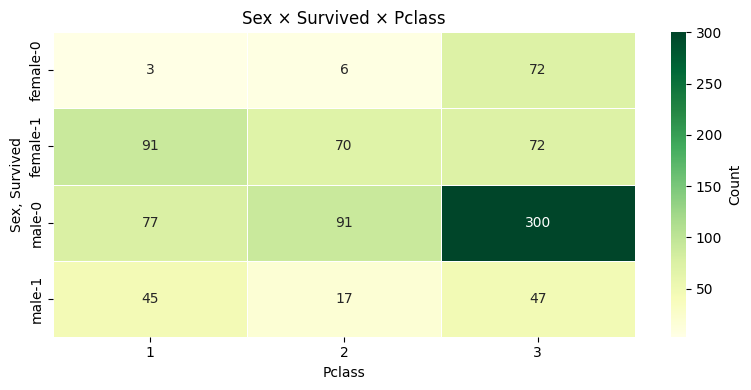

In [22]:
ct = pd.crosstab([df.Sex, df.Survived], df.Pclass, margins=False)
plt.figure(figsize=(8, 4))
sns.heatmap(
    ct,
    annot=True,      # числа в ячейках
    fmt='d',
    cmap='YlGn',     # аналог summer_r
    linewidths=0.5,
    cbar_kws={'label': 'Count'}
)
plt.title('Sex × Survived × Pclass')
plt.ylabel('Sex, Survived')
plt.xlabel('Pclass')
plt.tight_layout()
plt.show()

По тепловой карте выше, можно судить о выживаемости по полу и принадлежности к определенному классу, которым ехал пассажир.

Как можно заметить, среди первого класса выжили почти все женщины, также как и во втором классе, но в третье классе количество выживших и погибших женщин разделилось поровну.

Среди мужчин видна тенденция что с увеличением класса погибает все больше мужчин, но лучше интерпретировать результаты тепловой карты не в абсолютных значениях, а в относительных, что и рассмотрим далее.

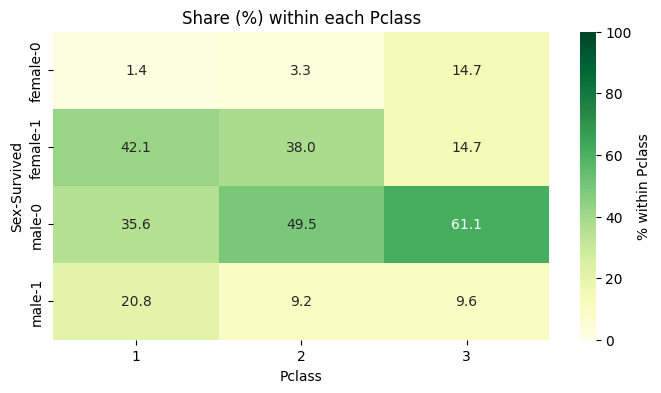

In [23]:
ct_pct = pd.crosstab(
    [df.Sex, df.Survived],
    df.Pclass,
    normalize='columns'
) * 100

plt.figure(figsize=(8, 4))
sns.heatmap(
    ct_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% within Pclass'}
)
plt.title('Share (%) within each Pclass')
plt.show()

На данной тепловой карте лучше виден процент выживаемости и смертности.

Отсюда можно сделать вывод, что из-за полититки спасения женщин их выживаемость была лучше во всех классах лучше чем у мужчин, но чем ниже был класс пассажира тем меньше шансов на выживание.

Откуда можно предварительно сделать вывод, что пол и принадлежность к определнному классу, будет сильно влиять при предсказании. Так как если ты мужчина и ты из третьего класса - считай что уже мертв).

In [24]:
print(f"Oldest passenger was of {df.Age.max():.2f} years")
print(f"Youngest passenger was of {df.Age.min():.2f} years")
print(f"Average age of passengers on the Titatic {df.Age.mean():.2f} years")

Oldest passenger was of 80.00 years
Youngest passenger was of 0.42 years
Average age of passengers on the Titatic 29.70 years


Text(0.5, 1.0, 'Age distribution')

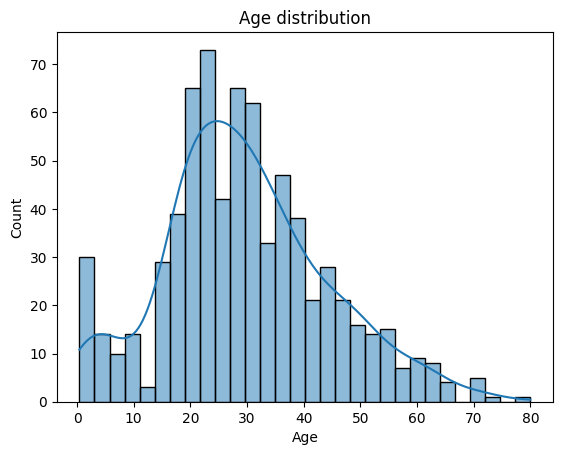

In [25]:
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Age distribution')

Здесь можно посмотреть на распределение пассажиров по возрасту, и заметить что подавляющее число людей было от 18 до 40 лет.

<Axes: xlabel='Survived', ylabel='Age'>

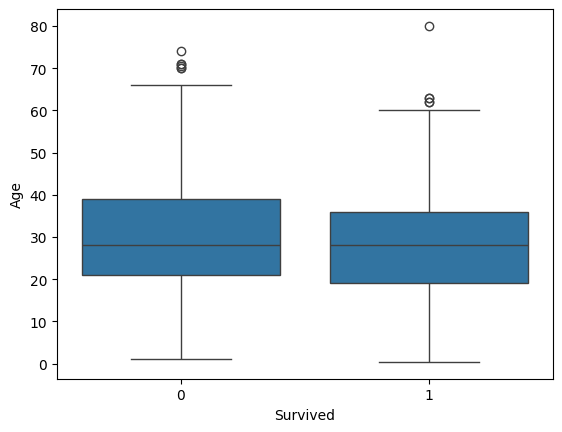

In [26]:
sns.boxplot(data=df, x='Survived', y='Age')


В среднем люди выжившие и умершие были одного возраста, это из-за количество пассажиров преимущественно одной возрастной группы, но можно заметить, что в целом выживали более молодые пассажиры, возможно на это повлияло в том числе и спасение детей.

Также можно заметить, что самого старшего пассажира тоже спасли.

Text(0.5, 1.0, 'Age by Pclass and Survived')

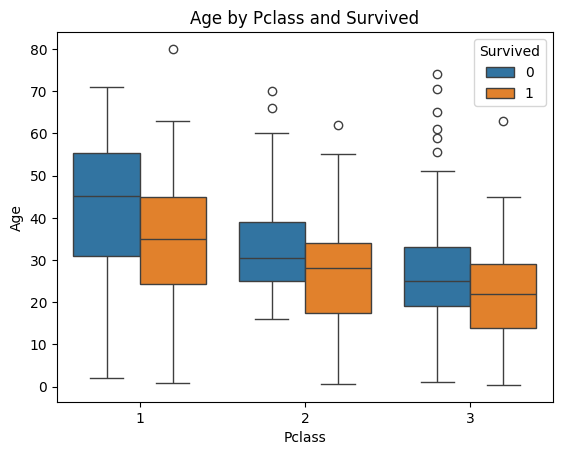

In [27]:
sns.boxplot(data=df, x='Pclass', y='Age', hue='Survived')
plt.title("Age by Pclass and Survived")

Выше видна статистика выживаемости в зависимости от принадлежности к классу и возраста.

Можно заметить тенденцию, что с повышением класса (от 1(лучший-люкс) к 3(худший)) снижается возраст выживших, скорее всего это связано с наличием детей, которые ехали этими классами

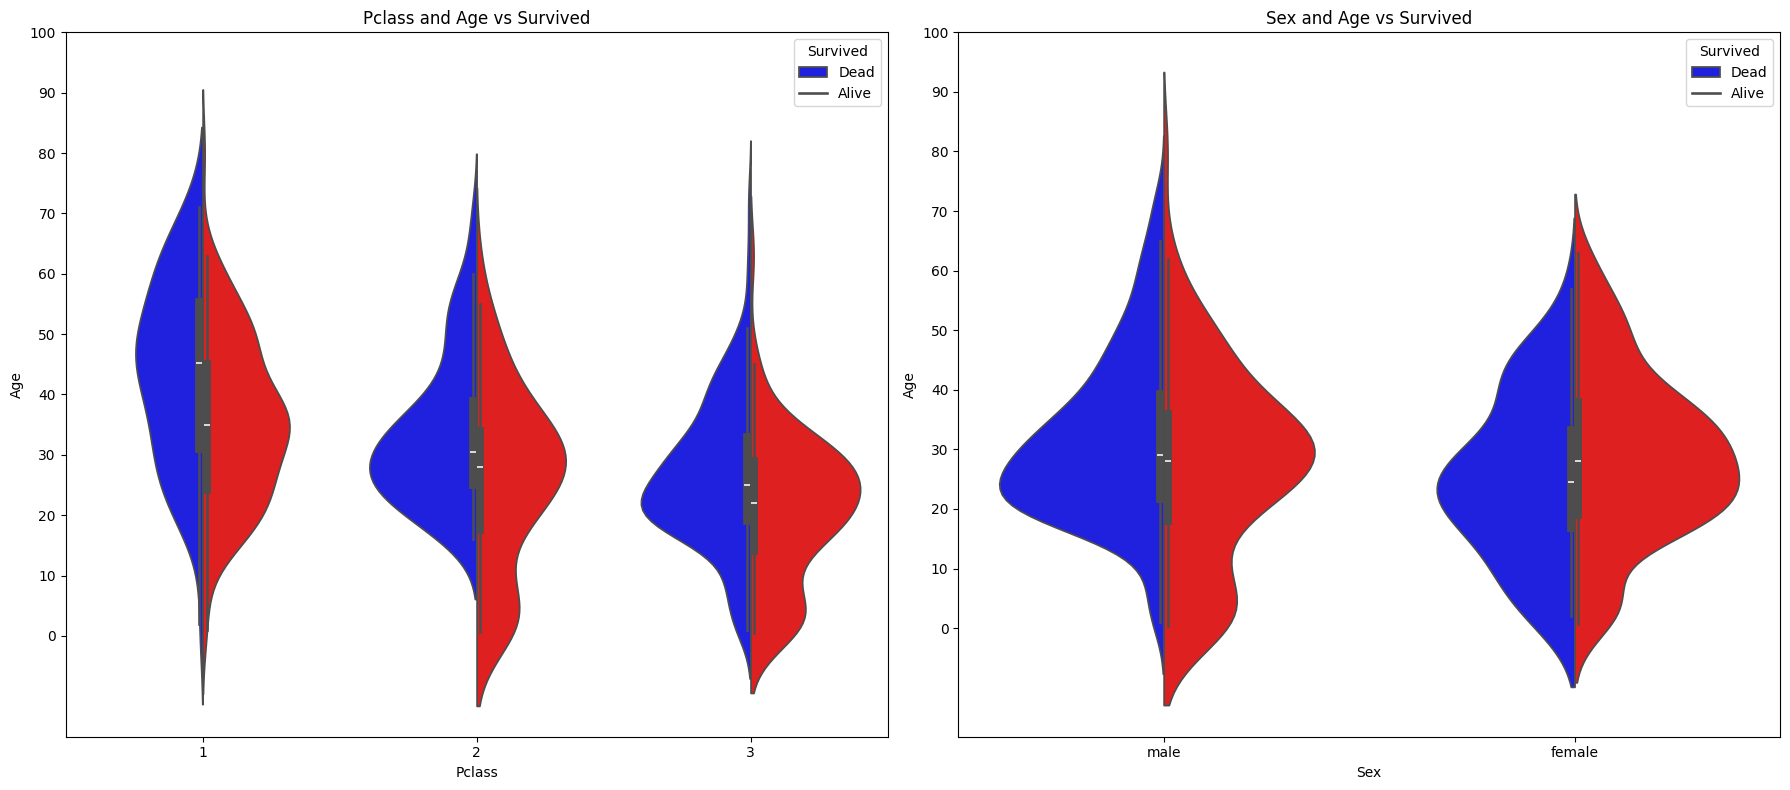

In [28]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

plot_df = df[['Pclass', 'Sex', 'Age', 'Survived']].dropna(subset=['Age'])

sns.violinplot(
    data=plot_df, x='Pclass', y='Age', hue='Survived',
    split=True, palette={0: 'blue', 1: 'red'}, ax=ax[0]
)
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_ylabel('Age')
ax[0].set_yticks(range(0, 110, 10))
ax[0].legend(title='Survived', labels=['Dead', 'Alive'])

sns.violinplot(
    data=plot_df, x='Sex', y='Age', hue='Survived',
    split=True, palette={0: 'blue', 1: 'red'}, ax=ax[1]
)
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_ylabel('Age')
ax[1].set_yticks(range(0, 110, 10))
ax[1].legend(title='Survived', labels=['Dead', 'Alive'])

plt.tight_layout()
plt.show()

Да, как и ожидалось снижение возраста выживших связано с тем, что в классах 2 и 3 ехали дети и их спасали. А на правом графике можно заметить, что преимущественно выживали женщины. 

В общем эти выводы совпадают с политикой сначала спасаем женщин и детей!

<Axes: xlabel='Sex', ylabel='Age'>

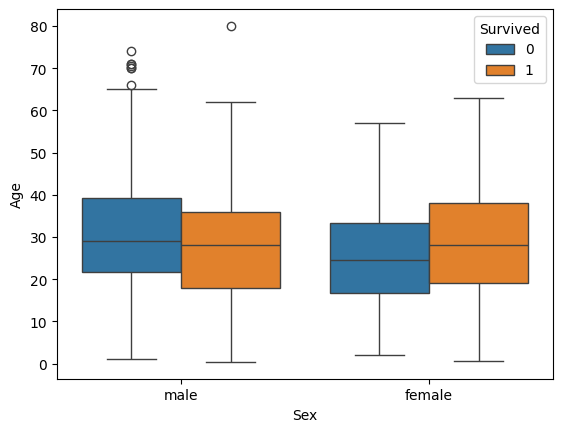

In [29]:
sns.boxplot(data=df, x='Sex', y='Age', hue='Survived')

Среди мужчин в среднем спасались и погибали люди одного возраста, но выживывали чуть моложе.

Среди женщин картина обратная, чаще спасались женщины чуть постарше (ближе к 30), а погибали помладше.

<Axes: xlabel='Fare', ylabel='Count'>

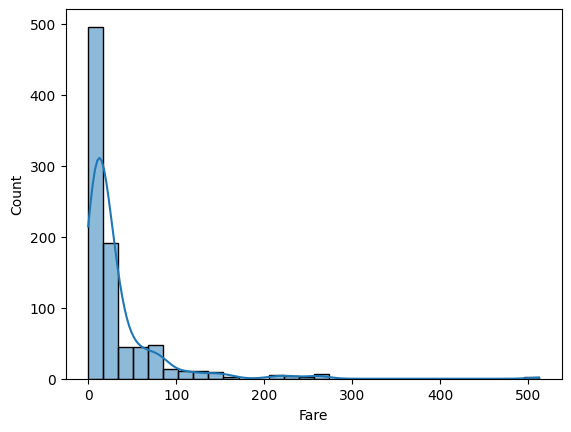

In [30]:
sns.histplot(df['Fare'].dropna(), bins=30, kde=True)

Распределение цены билета сильно скошено

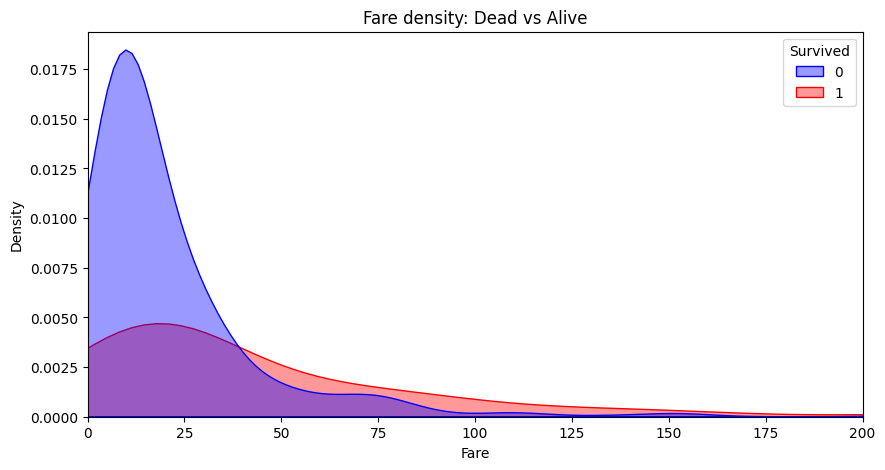

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='Fare', hue='Survived', fill=True,
            palette={0: 'blue', 1: 'red'}, alpha=0.4, ax=ax)
ax.set_xlim(0, 200)   # обрезать хвост для читаемости
ax.set_title('Fare density: Dead vs Alive')
plt.show()

Пассажиры с дорогими билетами имеют выше шанс на выживание

In [33]:
print('Highest Fare was:',df['Fare'].max())
print('Lowest Fare was:',df['Fare'].min())
print('Average Fare was:',df['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


In [34]:
df['Initial']=0
for i in df:
    df['Initial']=df.Name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations

In [35]:
pd.crosstab(df.Initial,df.Sex).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [36]:
title_map = {
    'Mlle': 'Miss', 'Mme': 'Miss', 'Ms': 'Miss',
    'Dr': 'Mr', 'Major': 'Mr', 'Lady': 'Mrs', 'Countess': 'Mrs',
    'Jonkheer': 'Other', 'Col': 'Other', 'Rev': 'Other',
    'Capt': 'Mr', 'Sir': 'Mr', 'Don': 'Mr',
}
df['Initial'] = df['Initial'].replace(title_map)

заменил в написании титулов на общие категории, проверив их по полу

In [37]:
df.groupby('Initial')['Age'].mean() #lets check the average age by Initials

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

Заполнил пропуски по возрасту среди категорий у которых отсутвовало значение на среднее значение по категории.

In [38]:
## Assigning the NaN Values with the Ceil values of the mean ages
df.loc[(df.Age.isnull())&(df.Initial=='Mr'),'Age']=33
df.loc[(df.Age.isnull())&(df.Initial=='Mrs'),'Age']=36
df.loc[(df.Age.isnull())&(df.Initial=='Master'),'Age']=5
df.loc[(df.Age.isnull())&(df.Initial=='Miss'),'Age']=22
df.loc[(df.Age.isnull())&(df.Initial=='Other'),'Age']=46

In [39]:
df.Age.isnull().any() #So no null values left finally 

np.False_

Пропусков по возрасту больше нет.

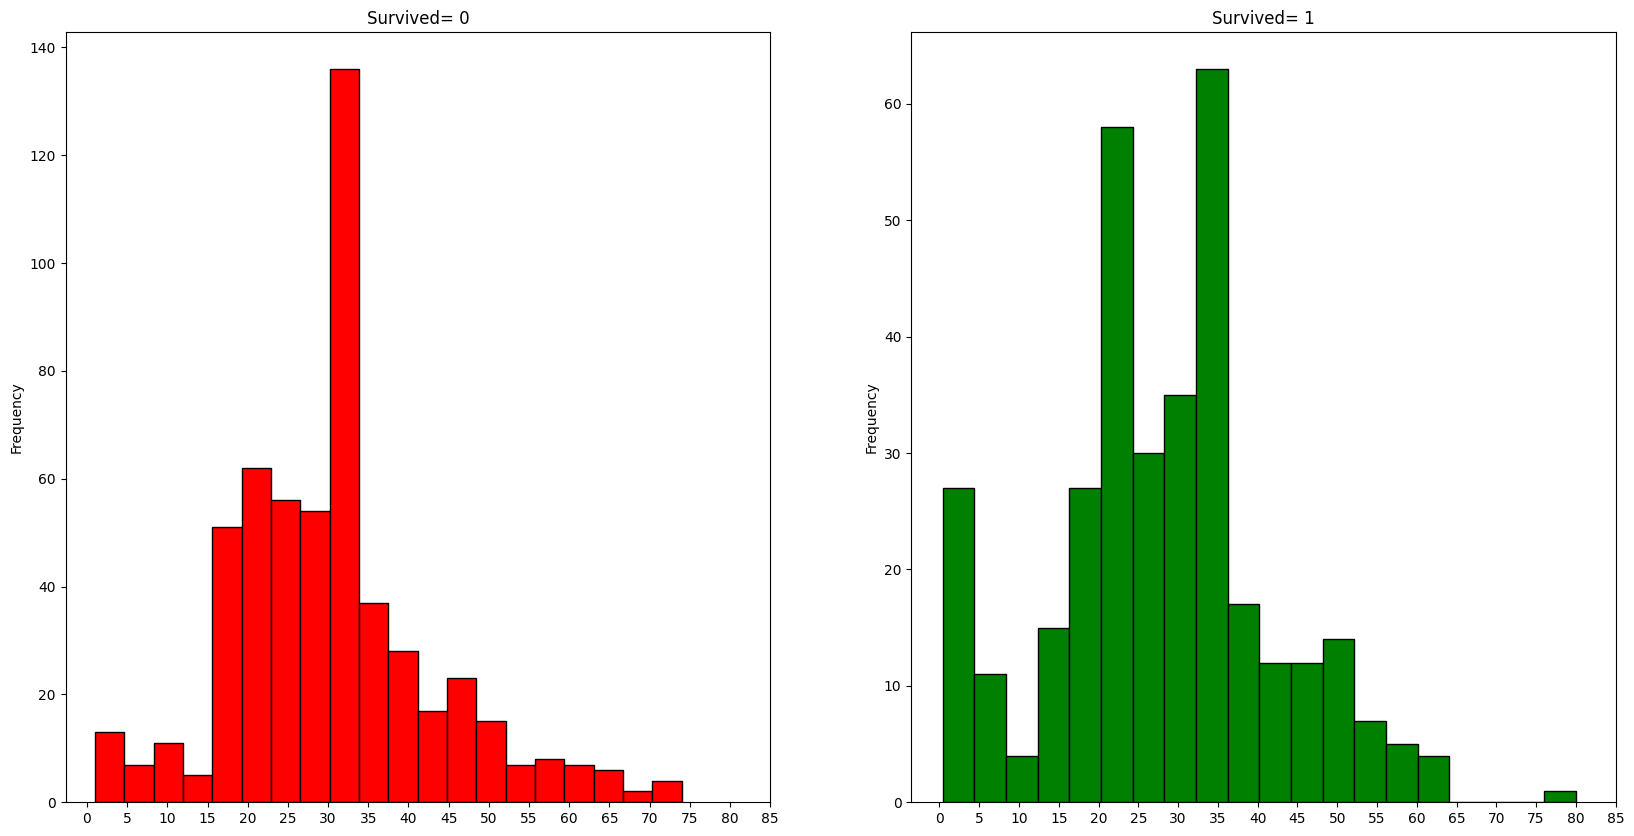

In [40]:
f,ax=plt.subplots(1,2,figsize=(20,10))
df[df['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
ax[0].set_xticks(np.arange(0, 86, 5))
df[df['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
ax[1].set_xticks(np.arange(0, 86, 5))
plt.show()

1) Наибольшая смертность от 30 до 40 лет
2) Много спасенных детей младше 10 лет
3) Самый старший пассажир также был спасен (Ранее выяснили - он из первого класса.)

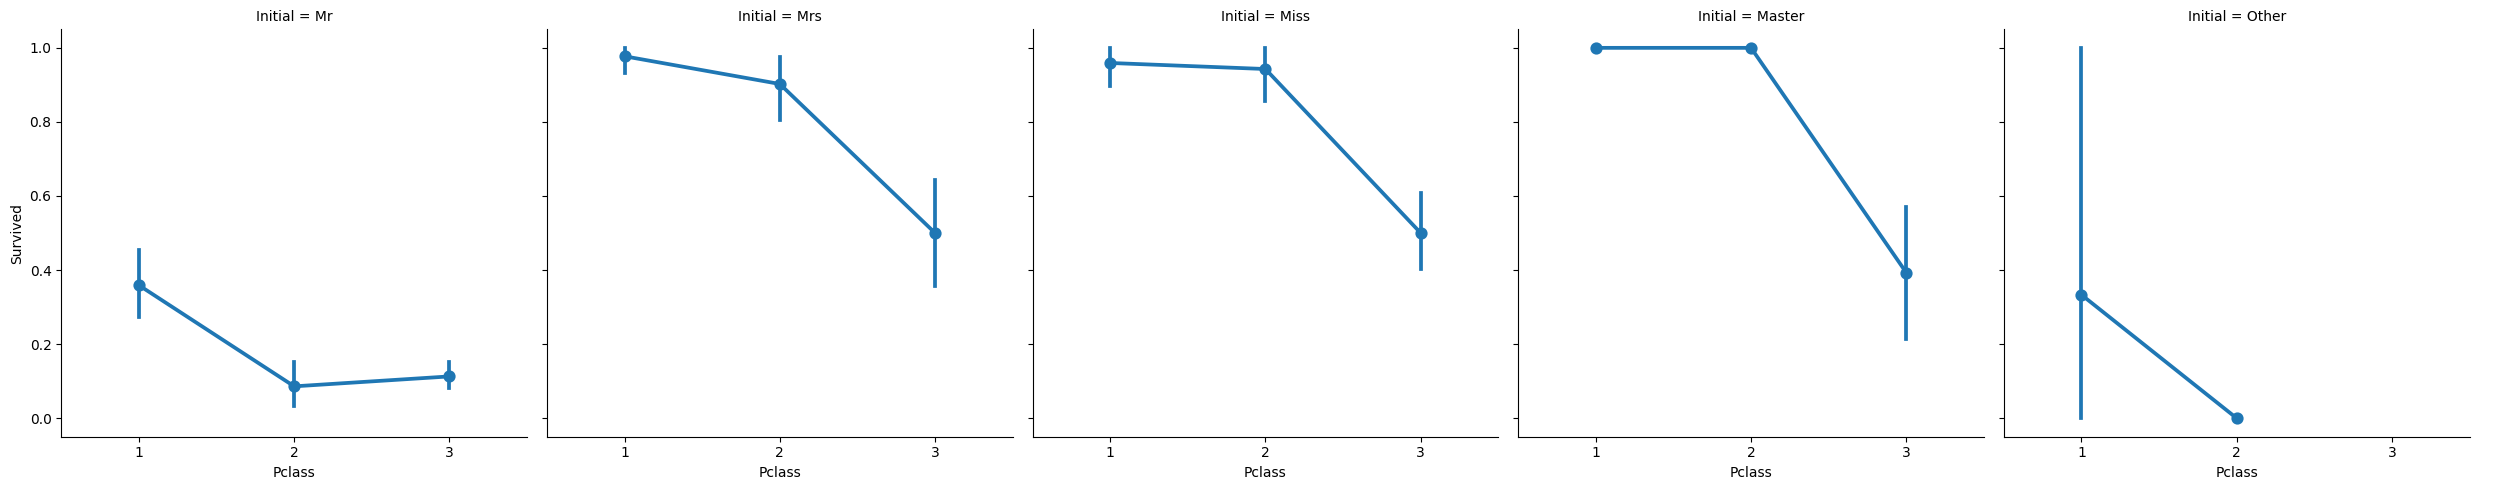

In [41]:
sns.catplot(x='Pclass', y='Survived', col='Initial', data=df, kind='point')
plt.show()

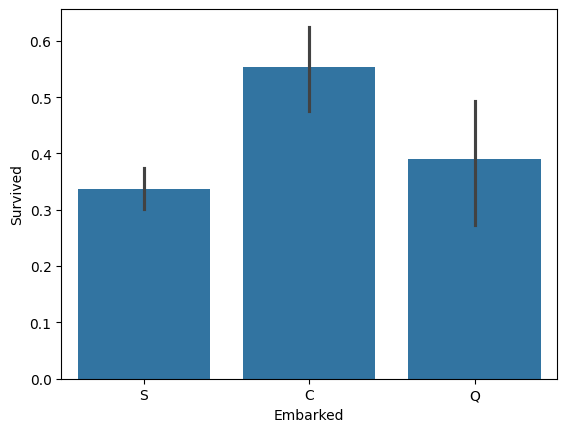

In [42]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.show()

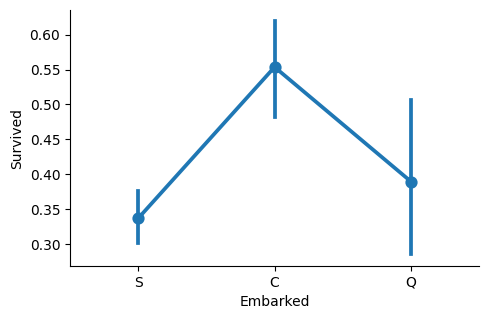

In [43]:
sns.catplot(x='Embarked',y='Survived',data=df, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

Выживаемость у людей, кто сел в порту С, выше и находится около 0.55 по сравнению с пассажирами севших в других портах. Самый низкий шанс на выживание у тех, кто сел в порту S - скорее всего в нем село большинство людей и они были из третьего класса.

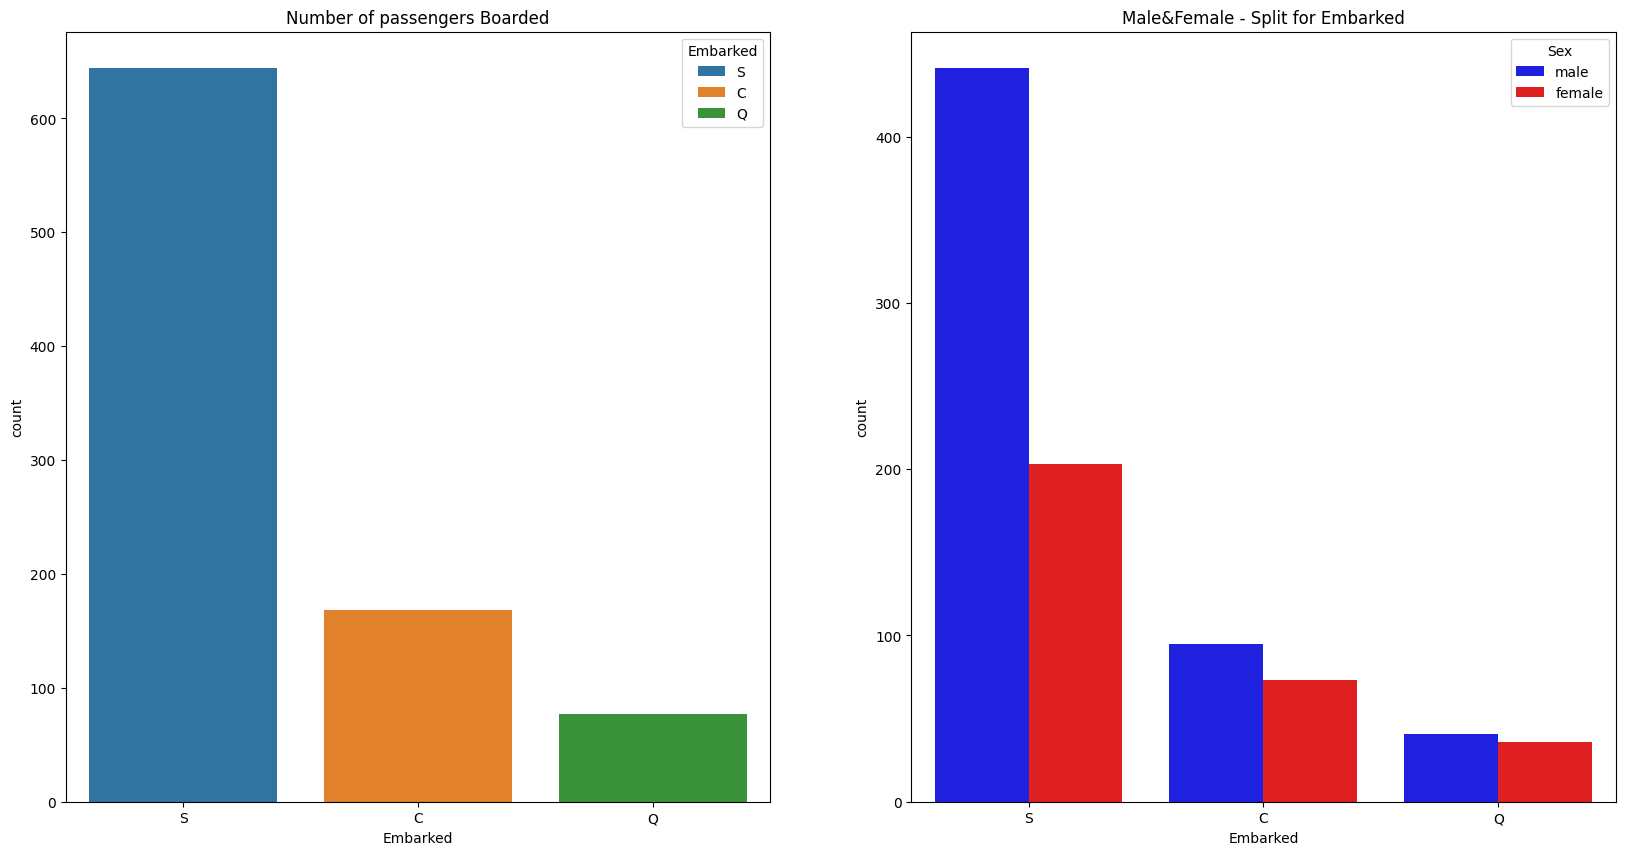

In [44]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, ax=ax[0], x='Embarked', hue='Embarked')
ax[0].set_title("Number of passengers Boarded")
sns.countplot(x='Embarked',hue='Sex', data=df, ax=ax[1], palette=['blue', 'red'])
ax[1].set_title("Male&Female - Split for Embarked")
plt.show()

Предыдущие предположение подтвердилось, что большинство людей село в порту S, также выяснилось что больше всего мужчин село именно в этом порту.

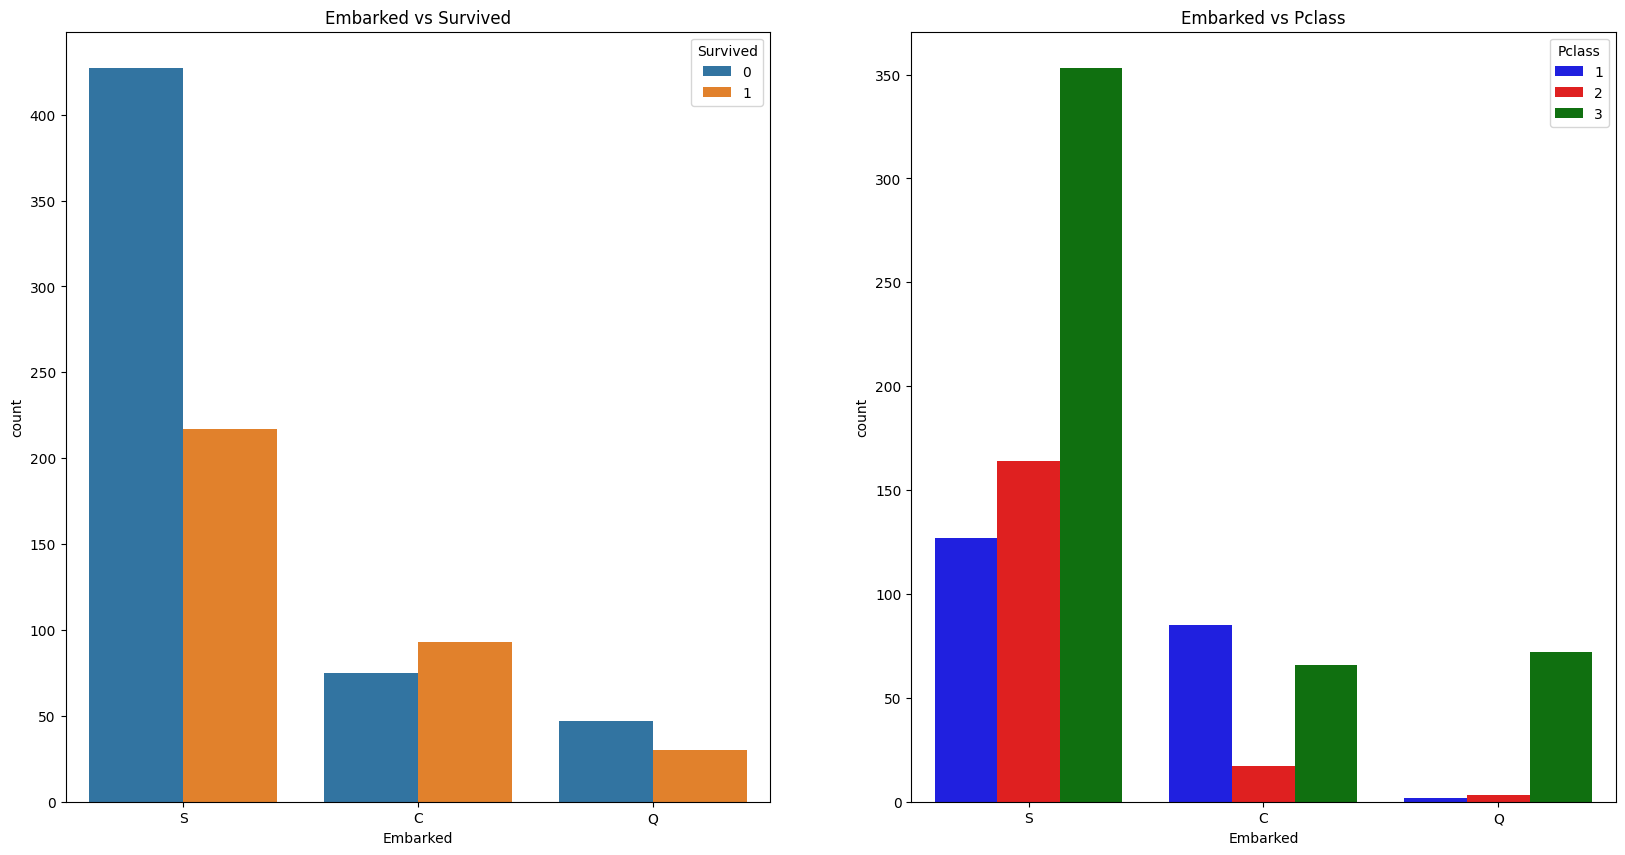

In [45]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, ax=ax[0], x='Embarked', hue='Survived')
ax[0].set_title("Embarked vs Survived")
sns.countplot(x='Embarked',hue='Pclass', data=df, ax=ax[1], palette=['blue', 'red', 'green'])
ax[1].set_title("Embarked vs Pclass")
plt.show()

Наибольшая выживаемость достигнута для людей севших в порту C, и как можно заметить, что там село достаочно большое кол-во пассажиров первого класса.


Также благодаря пассажирам первого класса выживаемость пассажиров из порта S тоже высокая.

Предыдщуие допущение о том, что большинство пассажиров третьего класса сели в порту S подтвердилось.

Преимущественно пассажиры из порта Q оказались пассажирами третьего класса.

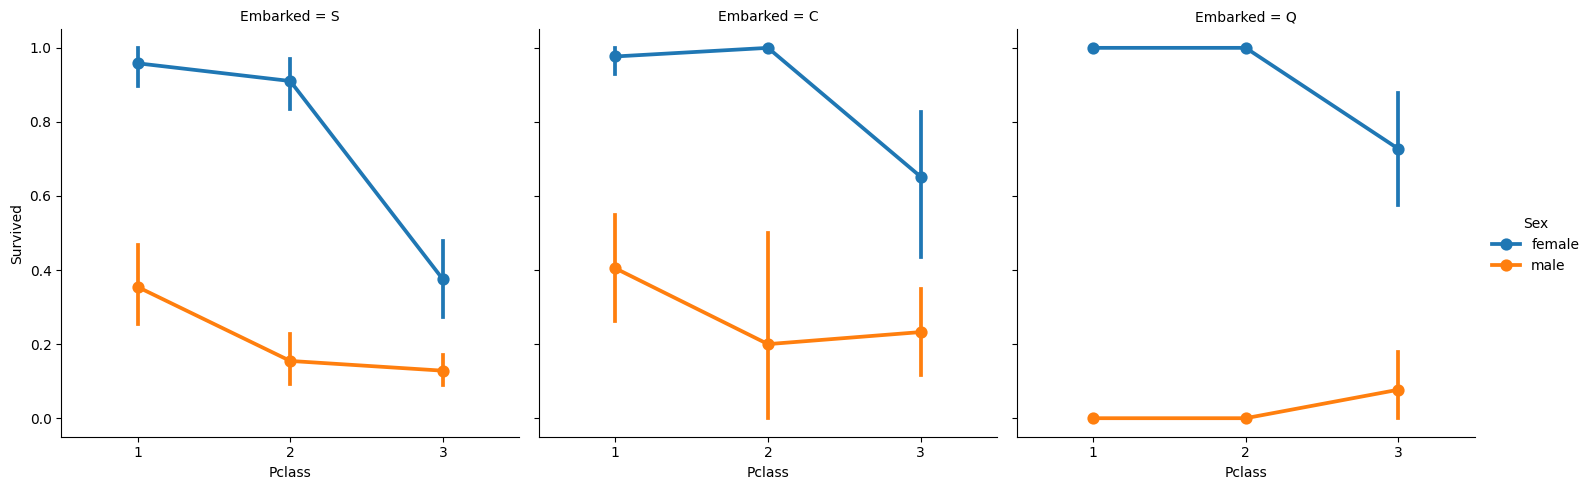

In [46]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',col='Embarked',data=df, kind='point')
plt.show()

Сравнение выживаемости пассажиров в зависимости от порта отправления, пола и приналденжости к классу показыает, что:
1) Выживаемость женщин в независимости от порта, но из первого и второго класса почти единица.
2) Для людей севших в порту S из третьего класса оказывается самым не удачным.
3) Для мужчин в целом самым худшим можно считать порт Q, учитывая особенно что почти все пассажиры оттуда из третьего класса.

In [47]:
df['Embarked'] = df['Embarked'].fillna('S')

In [48]:
df.Embarked.isnull().any()

np.False_

Заполнили пропуски в данных на самый популярный порт

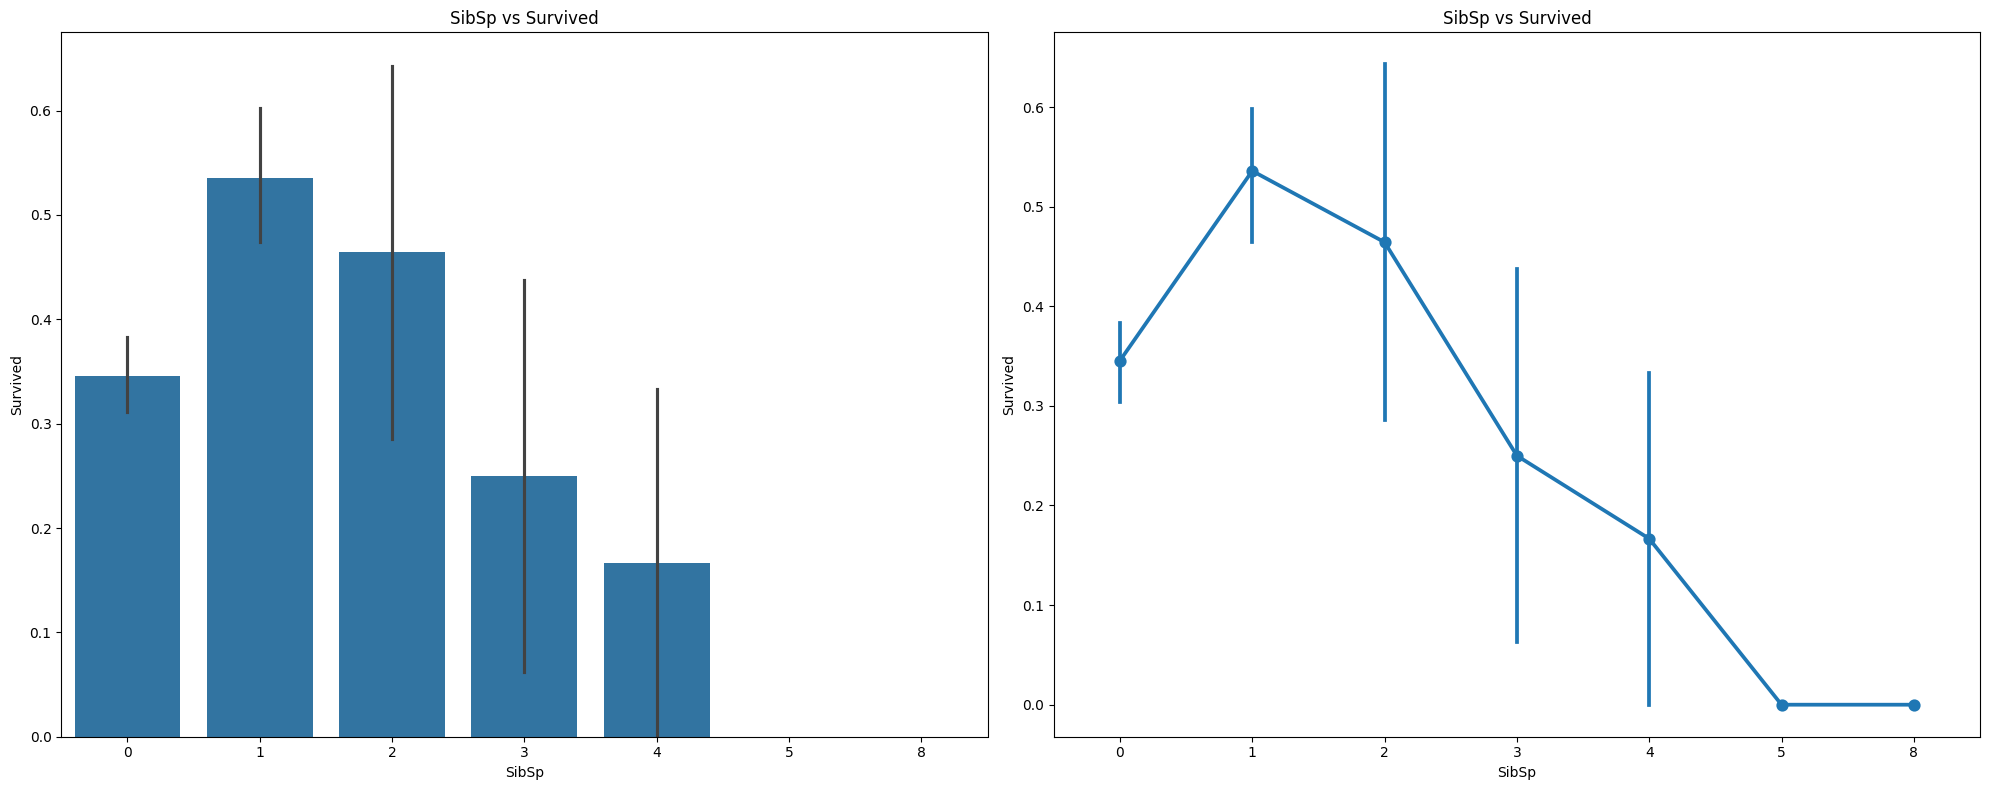

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='SibSp', y='Survived', data=df, ax=ax[0])
ax[0].set_title('SibSp vs Survived')

# pointplot — осевой график (принимает ax=); catplot — отдельная figure
sns.pointplot(x='SibSp', y='Survived', data=df, ax=ax[1])
ax[1].set_title('SibSp vs Survived')

plt.tight_layout()
plt.show()

In [50]:
pd.crosstab(df.SibSp,df.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


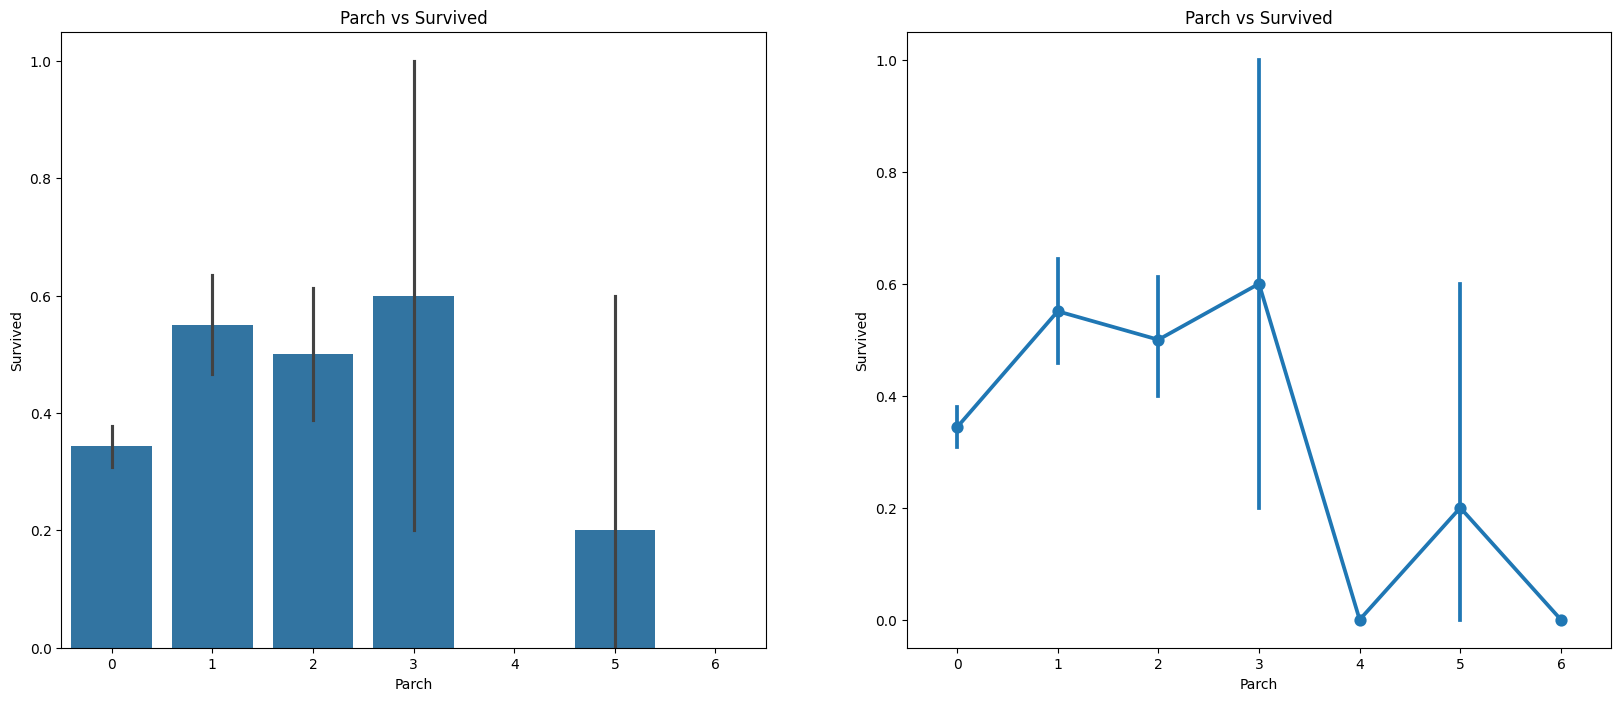

In [53]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.barplot(x='Parch',y='Survived',data=df,ax=ax[0])
ax[0].set_title('Parch vs Survived')
sns.pointplot(x='Parch',y='Survived',data=df,ax=ax[1])
ax[1].set_title('Parch vs Survived')
plt.close(2)
plt.show()

Можно заметить, что выживаемость у одиноких людей и людей у которых больше 3 родственников ниже чем у тех, у кого есть близкие люди от 1 до 3 штук.

Это общий вывод на два признака SibSp и Parch - в будущем стоит объединить в один признак.

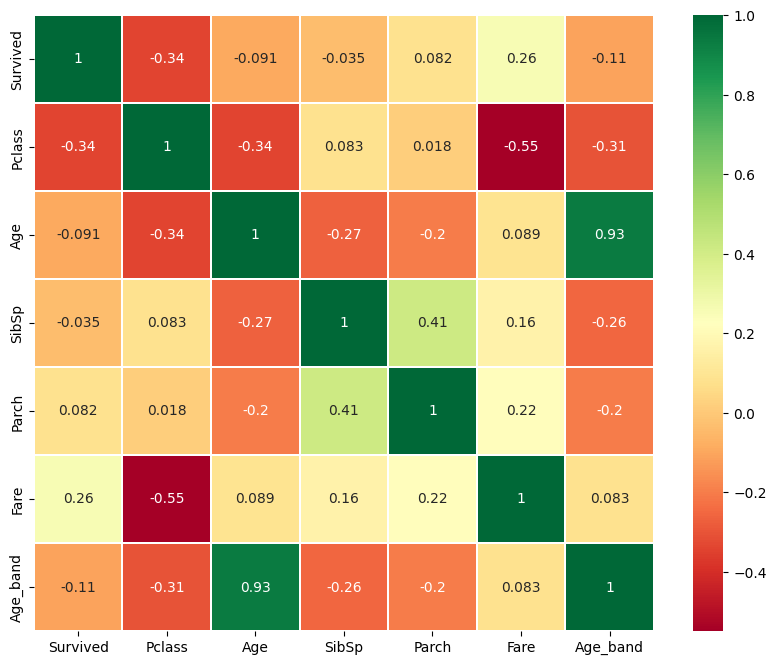

In [52]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', linewidths=0.2)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.show()

### Feature Engineering and clean data

Так как возраст непрерывная фича, удобно будет ее сделать категориальной и поделить людей по категориям.

In [51]:
df['Age_band']=0
df.loc[df['Age']<=16,'Age_band']=0
df.loc[(df['Age']>16)&(df['Age']<=32),'Age_band']=1
df.loc[(df['Age']>32)&(df['Age']<=48),'Age_band']=2
df.loc[(df['Age']>48)&(df['Age']<=64),'Age_band']=3
df.loc[df['Age']>64,'Age_band']=4
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [54]:
df['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')#checking the number of passenegers in each band

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


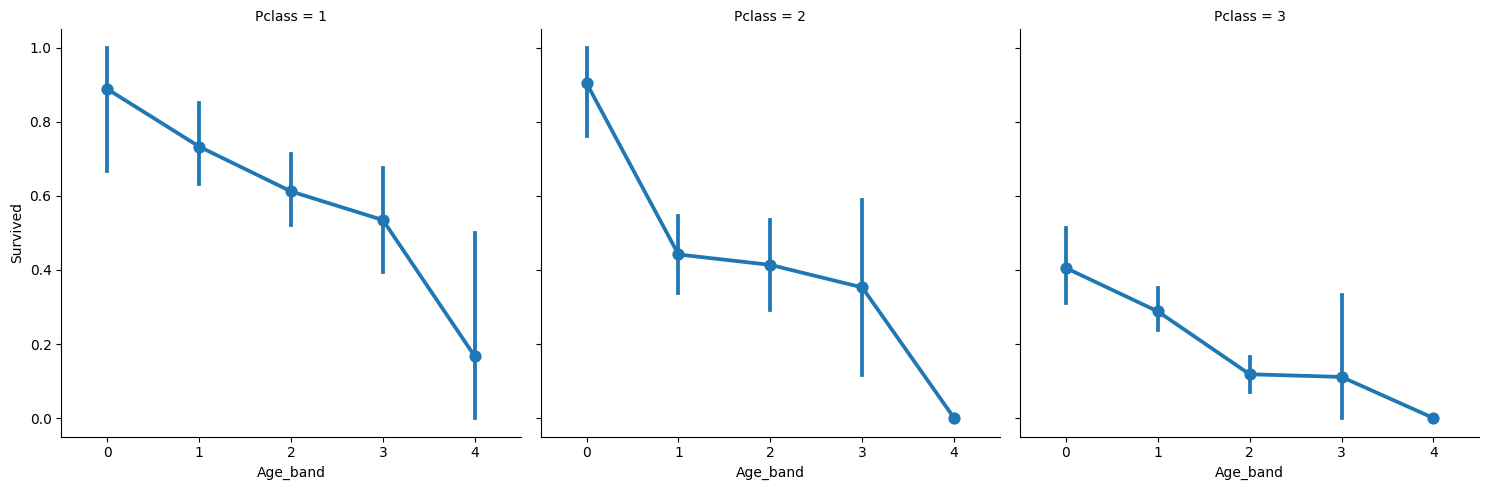

In [55]:
sns.catplot(x='Age_band',y='Survived',data=df,col='Pclass', kind='point')
plt.show()

Во всех классах выживали люди более молодые

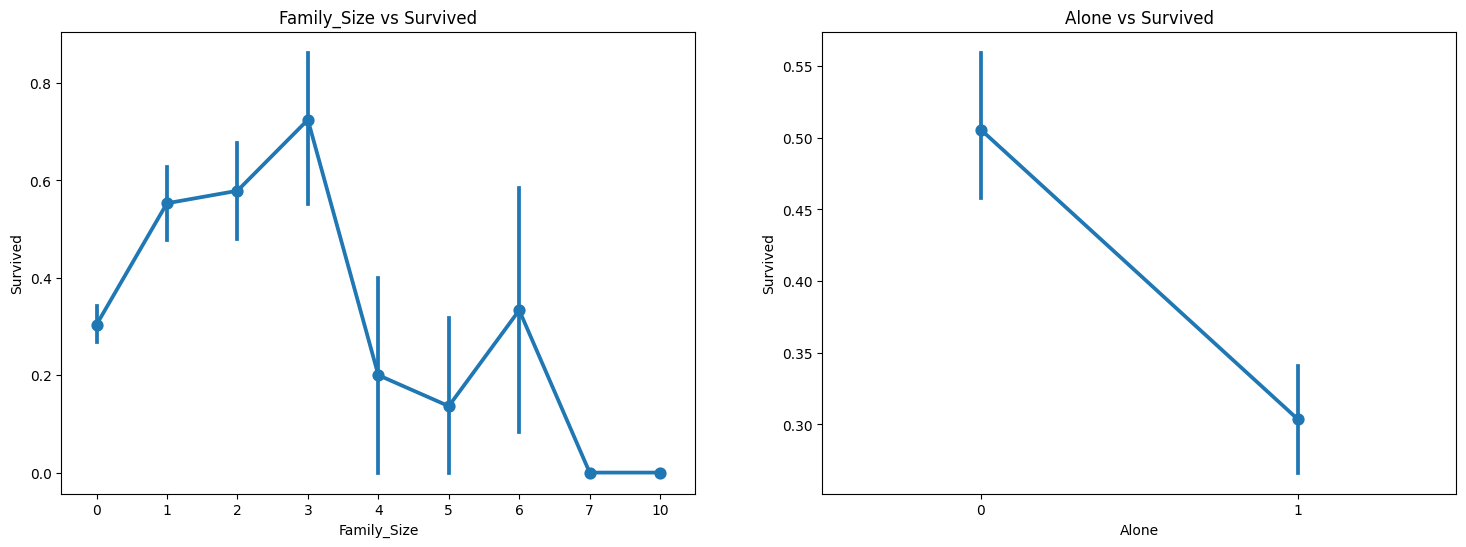

In [56]:
df['Family_Size']=0
df['Family_Size']=df['Parch']+df['SibSp']#family size
df['Alone']=0
df.loc[df.Family_Size==0,'Alone']=1#Alone

f,ax=plt.subplots(1,2,figsize=(18,6))
sns.pointplot(x='Family_Size',y='Survived',data=df,ax=ax[0])
ax[0].set_title('Family_Size vs Survived')
sns.pointplot(x='Alone',y='Survived',data=df,ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()

Объединили в общую фичу размер семьи = SibSp + Parch

Также показали, что у одиноких людей шансов выжить меньше.

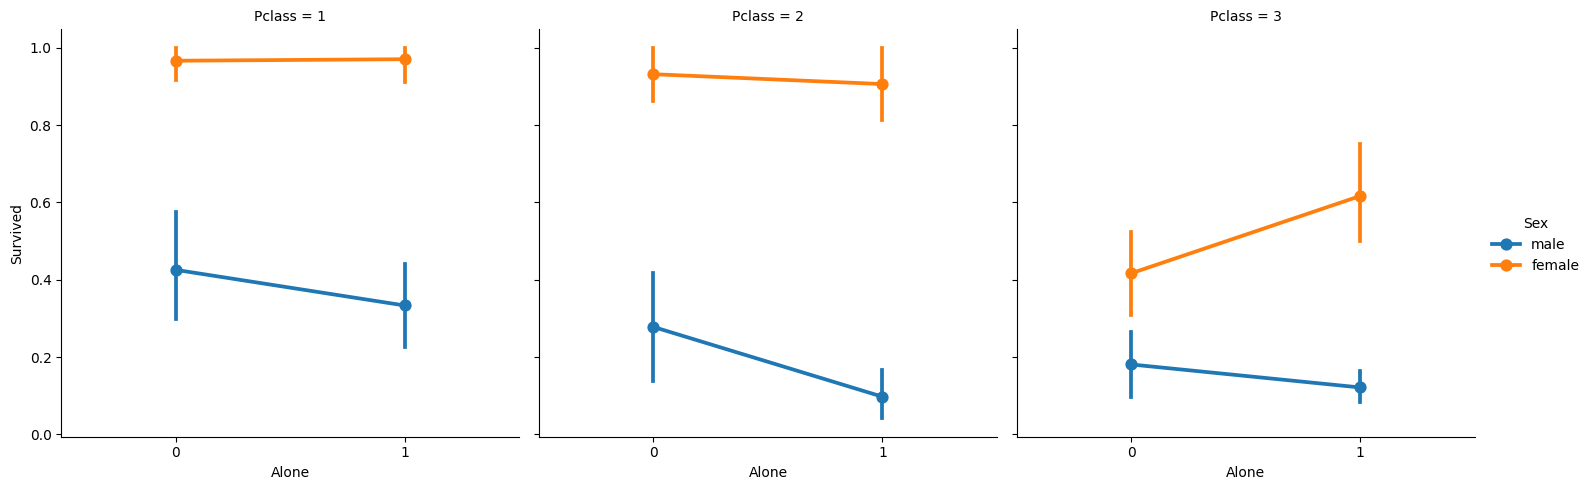

In [57]:
sns.catplot(x='Alone',y='Survived',data=df,hue='Sex',col='Pclass', kind='point')
plt.show()

Цена билетов также была непрерывной фичей, разибили ее на категории, так как можно подметить факт, что если билет был дороже - то скорее всего он относится к первому классу,а значит выжиываемость выше.

In [58]:
# так же нужно поступить со стоимостью билетов, разобьем их на разные ценовые диапазоны

df['Fare_Range']=pd.qcut(df['Fare'],4)
df.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


In [59]:
df['Fare_cat']=0
df.loc[df['Fare']<=7.91,'Fare_cat']=0
df.loc[(df['Fare']>7.91)&(df['Fare']<=14.454),'Fare_cat']=1
df.loc[(df['Fare']>14.454)&(df['Fare']<=31),'Fare_cat']=2
df.loc[(df['Fare']>31)&(df['Fare']<=513),'Fare_cat']=3

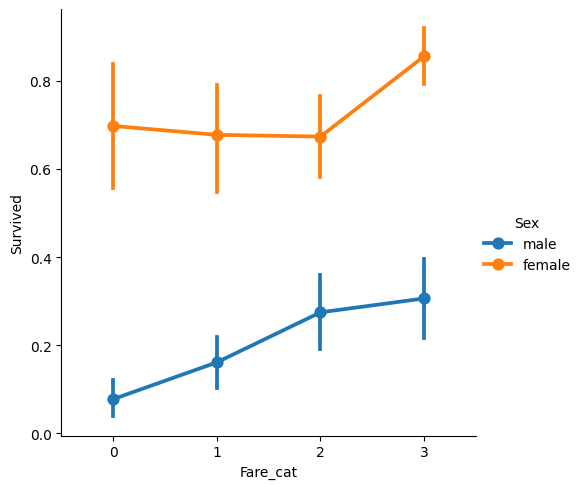

In [60]:
sns.catplot(x='Fare_cat',y='Survived',data=df,hue='Sex', kind='point')
plt.show()

У женщин в независимости от стоимости билета высокая выживаемость, а среди мужчин цена билета увеличивает шансы на выживаемость, из-за корреляции цены билета и класса пассажира.

In [61]:
df['Sex'] = df['Sex'].replace(['male', 'female'], [0, 1])
df['Embarked'] = df['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2])
df['Initial'] = df['Initial'].replace(
    ['Mr', 'Mrs', 'Miss', 'Master', 'Other'],
    [0, 1, 2, 3, 4]
)

Закодировали категориальные фичи и удалили их исходники

Также удалили фичи, которые нельзя как-то интерпретировать для предсказания или имеющих много пропусков и нет возможности их заполнить чем-то осмысленным.

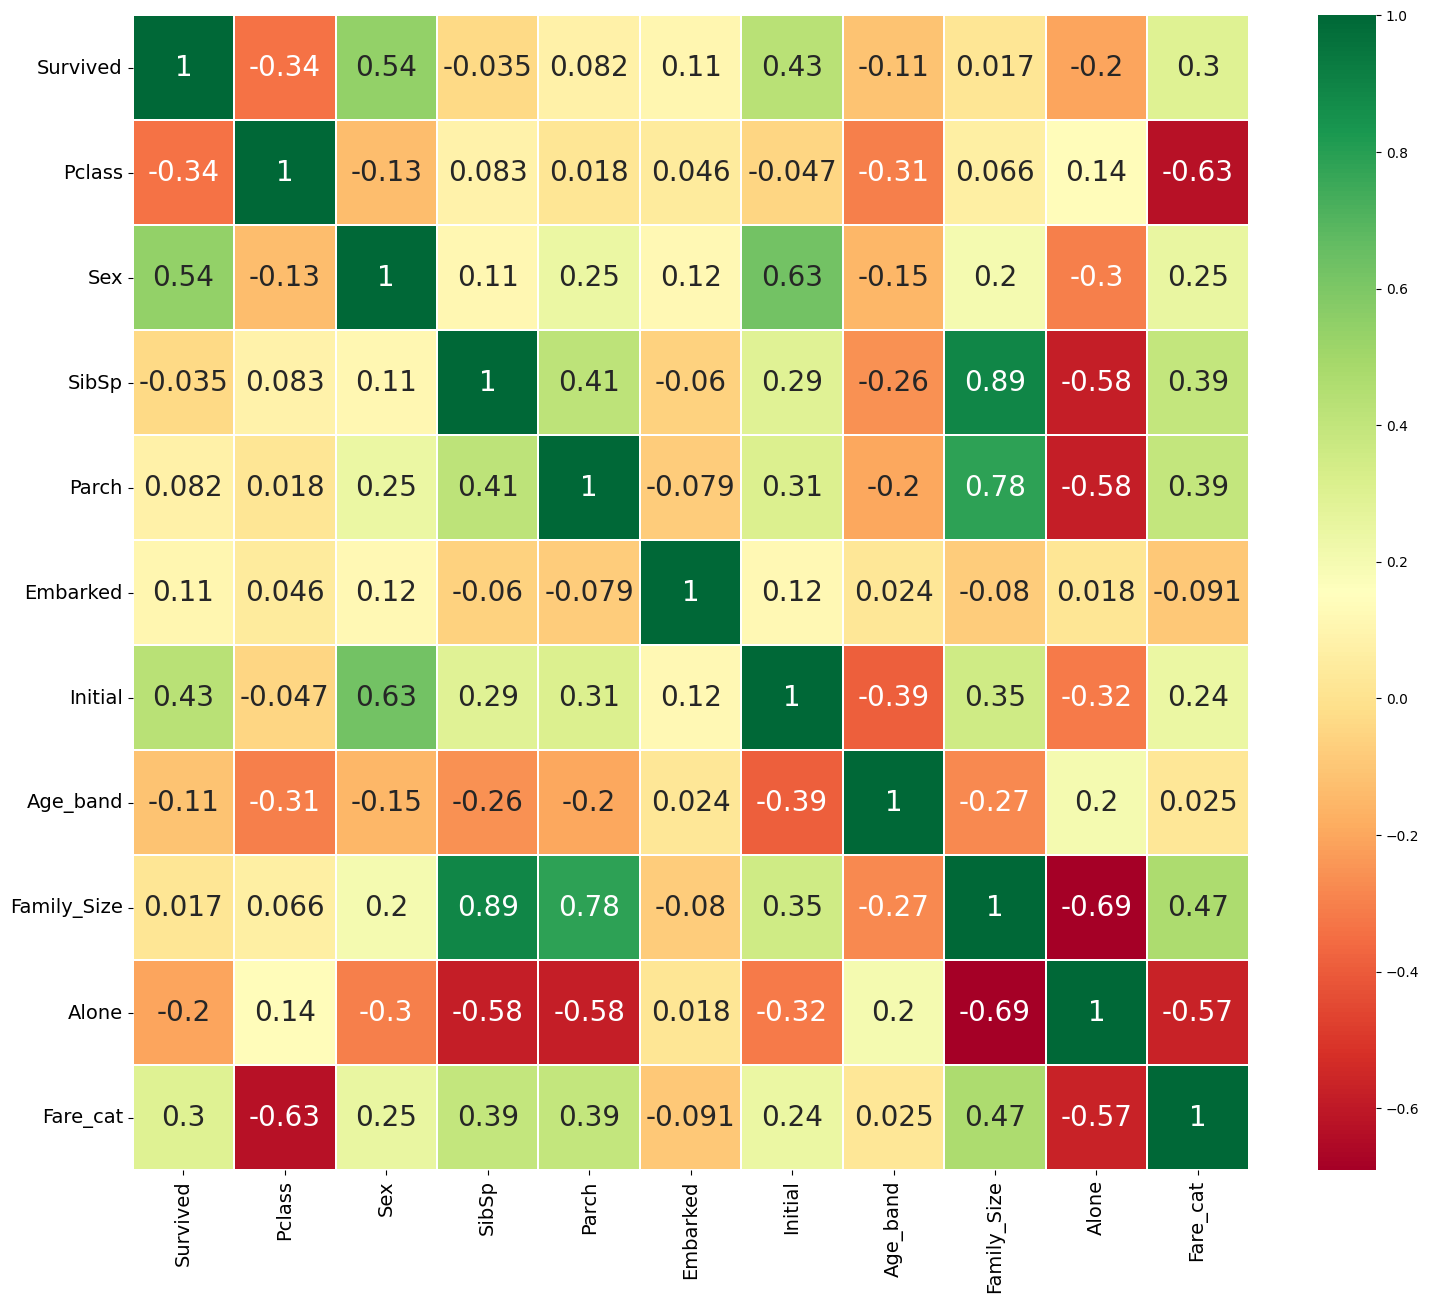

In [62]:
df.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range'],axis=1,inplace=True)
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':20})
fig=plt.gcf()
fig.set_size_inches(18,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [63]:
df.dtypes

Survived        int64
Pclass          int64
Sex            object
SibSp           int64
Parch           int64
Embarked       object
Initial        object
Age_band        int64
Family_Size     int64
Alone           int64
Fare_cat        int64
dtype: object

In [64]:
df['Sex'] = df['Sex'].astype(int)
df['Embarked'] = df['Embarked'].astype(int)
df['Initial'] = df['Initial'].astype(int)

In [65]:
df.dtypes

Survived       int64
Pclass         int64
Sex            int64
SibSp          int64
Parch          int64
Embarked       int64
Initial        int64
Age_band       int64
Family_Size    int64
Alone          int64
Fare_cat       int64
dtype: object

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Survived     891 non-null    int64
 1   Pclass       891 non-null    int64
 2   Sex          891 non-null    int64
 3   SibSp        891 non-null    int64
 4   Parch        891 non-null    int64
 5   Embarked     891 non-null    int64
 6   Initial      891 non-null    int64
 7   Age_band     891 non-null    int64
 8   Family_Size  891 non-null    int64
 9   Alone        891 non-null    int64
 10  Fare_cat     891 non-null    int64
dtypes: int64(11)
memory usage: 76.7 KB


Финальная проверка всех фич на возмонжость их использования при обучении.

### Финальные выводы по представленным данным


1) Самым важным признаком можно назвать пол(Sex);
2) Также не маловажную роль будет играть класс(Pclass) которым ехал пассажир;
3) Стоимость билета(Fare), тоже может увеличить шансы на выживаемость - коррелирует с классом которым ехал пассажир;
4) Одинокий пассажир(Alone) или с большим количеством родственников(Family_Size) скорее всего погибнет, оптимально от 1 до 3 близких
5) Возраст(Age) скорее не показатель выживаемости, но если попасть в категорию детей, то выживаемость повысится 